# Análisis Exploratorio de Datos (EDA): Ventas Globales de Videojuegos

**Curso:** Analítica de Datos I · 
**Entrega:**  Entrega Evaluable EDA
**Docentes:** Yasmin Johanna García   
**Dataset elegido:** 04 — Global Video Game Sales 

---

## Integrantes del grupo

| Nombre completo | Código |
|---|---|
| Laura Fernandez  | A00410462 |
|  Manuela Calero | A00409149 |
| Alejandro Valencia  | A00409962 |
| Freddy Trochez  | A00411060 |

---

## Justificación de la elección del dataset

Elegimos el dataset **Global Video Game Sales** porque combina, en un mismo conjunto de datos, variables numéricas continuas (ventas por región), variables categóricas (plataforma, género, publisher) y una variable temporal (año de lanzamiento). Esto nos permite recorrer las ocho secciones del taller sobre un dominio real, con errores genuinos (valores faltantes, posibles duplicados). Adicionalmente, la industria de los videojuegos es un tema que nos genera curiosidad genuina como grupo: entender qué géneros, plataformas y publishers dominan el mercado, y cómo cambian las preferencias entre regiones y a través del tiempo, tiene aplicaciones de negocio muy concretas (decisiones de inversión, priorización de plataformas, localización de lanzamientos).

## Preguntas de análisis

1. ¿Cómo ha evolucionado el volumen de ventas globales de videojuegos entre 1980 y 2016, y qué papel ha jugado cada región (Norteamérica, Europa, Japón y el resto del mundo)?
2. ¿Qué géneros y plataformas concentran la mayor parte de las ventas globales, y esto ha cambiado a lo largo de las décadas?
3. ¿Qué publishers dominan el mercado, y su liderazgo se explica más por el volumen de títulos lanzados o por las ventas promedio por título?
4. ¿Qué tan fuerte es la relación entre las ventas de las distintas regiones? ¿Existe alguna región cuyo comportamiento se aleje del patrón global?
5. ¿Las preferencias de género varían de forma importante entre décadas, reflejando cambios estructurales de la industria (por ejemplo, el auge de los shooters o la caída de los juegos de plataformas)?


---
## Sección 2 · Carga y exploración inicial

Importamos las librerías necesarias para el análisis (Pandas y NumPy para manipulación de datos, Matplotlib y Seaborn para visualización) y cargamos el dataset original. Mantenemos el DataFrame original (`df_raw`) intacto como respaldo; todas las manipulaciones de limpieza se harán sobre una **copia explícita** en la Sección 3, siguiendo buenas prácticas de limpieza de datos.

> **Nota:** Se asume que el archivo `vgsales.csv` está ubicado en la misma carpeta que el notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

# Cargamos el dataset original; df_raw NO se modifica en ningún momento del análisis
df_raw = pd.read_csv('vgsales.csv')
print(f"Dimensiones del dataset: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")

Dimensiones del dataset: 16598 filas x 11 columnas


Revisamos los tipos de datos originales que trae el archivo y una muestra de las primeras filas.

In [2]:
df_raw.info()
#La función info() nos proporciona un resumen conciso del DataFrame, 
# incluyendo el número de entradas, el tipo de datos de cada columna y la cantidad de valores no nulos. Esto nos ayuda a identificar posibles problemas de datos faltantes o inconsistencias en los tipos de datos.

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [3]:
df_raw.head(10)
#La funcion head() nos permite ver las primeras 10 filas del dataset,
#  lo que nos da una idea de cómo se ven los datos y qué tipo de información contiene cada columna.

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


**Primeras observaciones:**
- El dataset tiene 16.598 filas y 11 columnas: identificador (`Rank`), nombre del juego, plataforma, año, género, publisher, y cinco columnas de ventas (`NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, `Global_Sales`), todas en millones de unidades.
- `Year` está como `float64` en lugar de un tipo entero, es un primer indicio de valores faltantes en esa columna, que confirmaremos en la Sección 3.
- `Platform`, `Genre` y `Publisher` son variables categóricas de texto (`object`) con un número relativamente bajo de categorías distintas, ideales para countplots y tablas cruzadas.


---
## Sección 3 · Limpieza y preparación mínima

### 3.1 Copia explícita del dataset

Antes de modificar cualquier dato, creamos una copia explícita de `df_raw`. A partir de aquí, todo el trabajo de limpieza y transformación se realiza sobre `df`, dejando `df_raw` disponible como referencia auditable del dato original.


In [4]:
df = df_raw.copy()
#La función copy() crea una copia del DataFrame df_raw y la asigna a la variable df. Esto es útil para preservar el dataset original mientras se realizan manipulaciones o análisis en la copia.
print("Copia creada. df_raw permanece intacto como respaldo del dataset original.")

Copia creada. df_raw permanece intacto como respaldo del dataset original.


### 3.2 Diagnóstico de valores faltantes

In [5]:
faltantes = df.isnull().sum()
faltantes_pct = (faltantes / len(df) * 100).round(2)
resumen_faltantes = pd.DataFrame({'faltantes': faltantes, '% del total': faltantes_pct})
resumen_faltantes[resumen_faltantes['faltantes'] > 0]

,faltantes,% del total
Year,271,1.63
Publisher,58,0.35


**Interpretación:** solo dos columnas tienen valores faltantes: `Year` (271 filas, ~1.6%) y `Publisher` (58 filas, ~0.35%). Ambos porcentajes son bajos, pero requieren un tratamiento distinto porque `Year` es central para el análisis temporal (Sección 7) mientras que `Publisher` es una variable categórica secundaria.

### 3.3 Diagnóstico de duplicados

In [6]:
print("Filas completamente duplicadas (todas las columnas iguales):", df.duplicated().sum())

# Buscamos duplicados "cercanos": mismo juego, misma plataforma y mismo año
posibles_dup = df[df.duplicated(subset=['Name', 'Platform', 'Year'], keep=False)].sort_values('Name')
posibles_dup

Filas completamente duplicadas (todas las columnas iguales): 0


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
603,604,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,2.11,0.23,0.00,0.22,2.56
16127,16130,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,0.00,0.01,0.00,0.00,0.01
14997,15000,Wii de Asobu: Metroid Prime,Wii,NaN,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02
14999,15002,Wii de Asobu: Metroid Prime,Wii,NaN,Shooter,Nintendo,0.00,0.00,0.02,0.00,0.02


**Interpretación:** no existen filas 100% duplicadas. Sin embargo, al buscar coincidencias por `Name` + `Platform` + `Year` aparecen 4 filas en 2 pares:

- **"Wii de Asobu: Metroid Prime" (Wii, año faltante):** dos filas prácticamente idénticas (mismas ventas en las 4 regiones). Como ambas tienen `Year` nulo, quedarán excluidas automáticamente al tratar los faltantes de `Year` en el siguiente paso, así que no requieren una acción adicional aquí.
- **"Madden NFL 13" (PS3, 2012):** dos filas con el mismo juego, plataforma y año, pero con ventas muy distintas (2.56M vs. 0.01M). La fila con 0.01M es casi con certeza un residuo de scraping (un registro incompleto que no debió duplicarse). Decidimos **eliminar esa fila residual** y conservar la fila con la información completa (2.56M), documentando la decisión de forma transparente en el siguiente paso.

### 3.4 Tratamiento justificado de faltantes y duplicados

In [7]:
# (1) Year faltante (1.63%): no existe una forma confiable de imputar el año de lanzamiento
#     de un videojuego (no se deriva de otras columnas), y es una variable central para el
#     análisis temporal (Sección 7). Dado el bajo porcentaje, descartamos estas filas.
df = df[df['Year'].notnull()].copy()

# (2) El dataset fue recolectado alrededor de 2016; los años 2017 (3 registros) y 2020
#     (1 registro) son residuos incompletos de esa recolección: mantenerlos generaría una
#     caída artificial y engañosa en el análisis temporal. Los excluimos y dejamos esta
#     limitación documentada para la Sección 8.
df = df[df['Year'] <= 2016].copy()

# (3) Publisher faltante (0.35%): no eliminamos estas filas (perderíamos ventas reales);
#     las marcamos con una categoría explícita "Desconocido" en lugar de imputar un publisher
#     arbitrario.
df['Publisher'] = df['Publisher'].fillna('Desconocido')

# (4) Duplicado justificado detectado en 3.3: eliminamos el registro residual de
#     'Madden NFL 13' (PS3, 2012) con ventas globales de 0.01M.
antes = df.shape[0]
df = df[~((df['Name'] == 'Madden NFL 13') & (df['Platform'] == 'PS3') &
          (df['Year'] == 2012) & (df['Global_Sales'] == 0.01))].copy()
print(f"Filas eliminadas por duplicado residual: {antes - df.shape[0]}")

print(f"\nDimensiones después de la limpieza: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Total de filas eliminadas respecto al original: {df_raw.shape[0] - df.shape[0]} "
      f"({(df_raw.shape[0] - df.shape[0]) / df_raw.shape[0] * 100:.1f}%)")

Filas eliminadas por duplicado residual: 1

Dimensiones después de la limpieza: 16322 filas x 11 columnas
Total de filas eliminadas respecto al original: 276 (1.7%)


Con estas decisiones eliminamos menos del 2% del dataset original y resolvemos tanto los faltantes como el único duplicado con evidencia real de ser un error de captura, preservando la mayor cantidad posible de información real de ventas.

### 3.5 Corrección de tipos de datos

In [8]:
# Year ya no tiene nulos, así que puede convertirse a entero sin problema
df['Year'] = df['Year'].astype(int)

# Las variables categóricas de baja cardinalidad se convierten a tipo 'category'
# (más eficiente en memoria y explícito sobre su naturaleza categórica)
for col in ['Platform', 'Genre', 'Publisher']:
    df[col] = df[col].astype('category')

df.dtypes

Rank               int64
Name                 str
Platform        category
Year               int64
Genre           category
Publisher       category
NA_Sales         float64
EU_Sales         float64
JP_Sales         float64
Other_Sales      float64
Global_Sales     float64
dtype: object

### 3.6 Creación de variables derivadas

Para enriquecer el análisis creamos tres variables nuevas que no existen en el dataset original:

- **`Decada`**: agrupa el año de lanzamiento en décadas (útil para observar tendencias de largo plazo sin el ruido año a año).
- **`Region_Dominante`**: identifica, para cada título, cuál de las 4 regiones (`NA`, `EU`, `JP`, `Other`) concentra la mayor proporción de sus ventas.
- **`Log_Global_Sales`**: transformación logarítmica de `Global_Sales` (solo para fines de visualización)  como veremos en la Sección 4, la variable original está fuertemente sesgada a la derecha, y `log1p()` permite apreciar mejor su forma real en los gráficos.

In [9]:
# Década de lanzamiento
df['Decada'] = ((df['Year'] // 10) * 10).astype(str) + 's'

# Región que domina las ventas de cada título
regiones = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
df['Region_Dominante'] = df[regiones].idxmax(axis=1).str.replace('_Sales', '', regex=False)

# Transformación logarítmica de Global_Sales, solo para visualización
df['Log_Global_Sales'] = np.log1p(df['Global_Sales'])

df[['Name', 'Year', 'Decada', 'Region_Dominante', 'Global_Sales', 'Log_Global_Sales']].head()

,Name,Year,Decada,Region_Dominante,Global_Sales,Log_Global_Sales
0,Wii Sports,2006,2000s,NA,82.74,4.427717
1,Super Mario Bros.,1985,1980s,NA,40.24,3.719409
2,Mario Kart Wii,2008,2000s,NA,35.82,3.606041
3,Wii Sports Resort,2009,2000s,NA,33.00,3.526361
4,Pokemon Red/Pokemon Blue,1996,1990s,NA,31.37,3.477232


Con esto cerramos la etapa de limpieza. El dataset de trabajo `df` queda listo, con datos correctos, sin faltantes, sin duplicados evidentes y con variables derivadas que usaremos en las siguientes secciones.

---
## Sección 4 · Análisis univariado

### Variables numéricas

**Pregunta que responde este gráfico:** ¿cómo se distribuyen las ventas globales por título? ¿La mayoría de los juegos vende cifras similares, o hay una gran disparidad entre ellos?

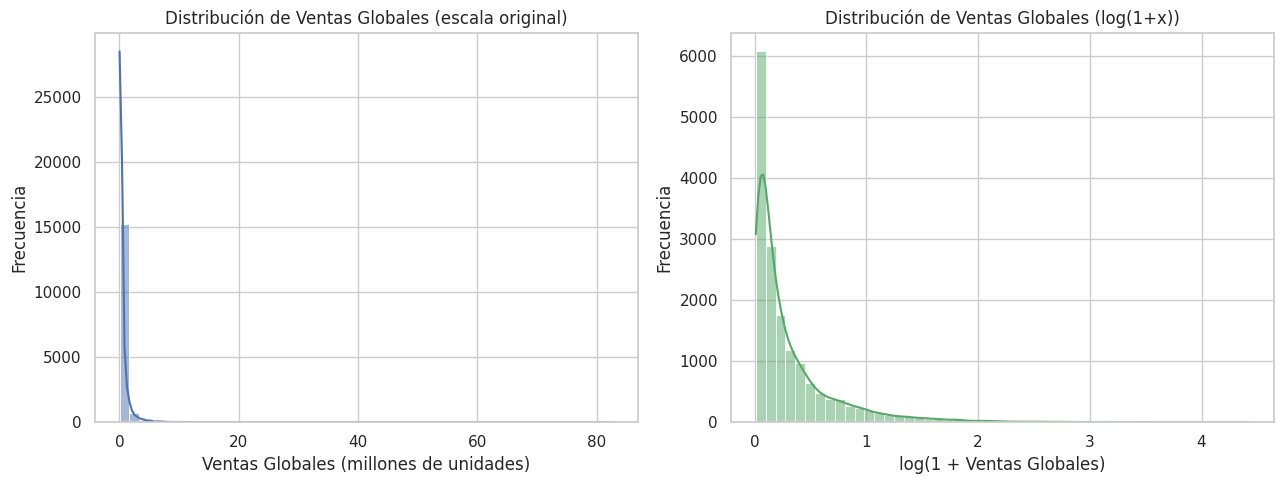

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['Global_Sales'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución de Ventas Globales (escala original)')
axes[0].set_xlabel('Ventas Globales (millones de unidades)')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['Log_Global_Sales'], bins=50, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Distribución de Ventas Globales (log(1+x))')
axes[1].set_xlabel('log(1 + Ventas Globales)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Interpretación:** en escala original, la distribución está extremadamente concentrada cerca de cero, con una cola larguísima hacia la derecha, es prácticamente ilegible sin transformar. En escala logarítmica se aprecia mejor la forma real: sigue siendo asimétrica a la derecha, pero permite distinguir la masa de juegos con ventas moderadas de los pocos títulos "blockbuster".

**Pregunta:** ¿cuánto se alejan la media y la mediana, y qué tan fuerte es la asimetría de las ventas globales?

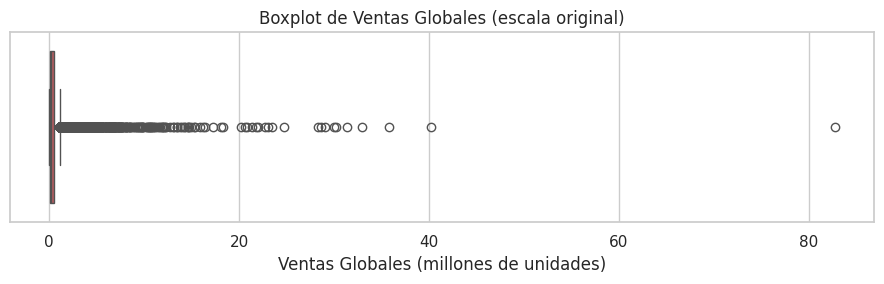

mean       0.540
median     0.170
std        1.566
skew      17.319
Name: Global_Sales, dtype: float64

In [11]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.boxplot(x=df['Global_Sales'], ax=ax, color='#C44E52')
ax.set_title('Boxplot de Ventas Globales (escala original)')
ax.set_xlabel('Ventas Globales (millones de unidades)')
plt.tight_layout()
plt.show()

medidas_global = df['Global_Sales'].agg(['mean', 'median', 'std', 'skew']).round(3)
medidas_global

**Interpretación:** la media  es más de 3 veces la mediana , y el coeficiente de asimetría  confirma un sesgo extremo a la derecha. El boxplot muestra una enorme cantidad de valores atípicos hacia la derecha: son los títulos verdaderamente exitosos, mientras la mayoría de los juegos vende cifras modestas. Este patrón es típico de industrias "hit-driven" (dominadas por unos pocos éxitos).

**Pregunta:** hasta aquí describimos `Global_Sales`, pero el dataset tiene cuatro variables numéricas más (una por región). ¿Se comportan todas igual, o cada mercado tiene una forma de distribución propia?

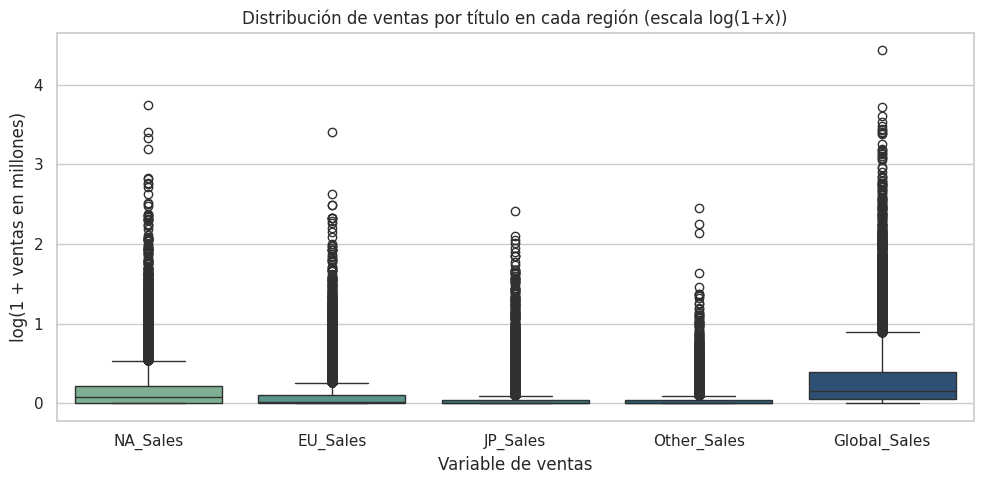

El 5% de títulos más vendidos concentra el 44.6% de las ventas globales.


,mean,median,std,skew,max,% ceros
NA_Sales,0.265,0.08,0.822,18.756,41.49,27.172
EU_Sales,0.148,0.02,0.509,18.791,29.02,34.457
JP_Sales,0.079,0.00,0.312,11.134,10.22,62.731
Other_Sales,0.048,0.01,0.190,24.123,10.57,38.966
Global_Sales,0.540,0.17,1.566,17.319,82.74,0.000


In [12]:
regiones_num = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# Medidas de tendencia central, dispersión y forma para cada variable de ventas
resumen_num = df[regiones_num].agg(['mean', 'median', 'std', 'skew', 'max']).T
# Añadimos el porcentaje de títulos sin ninguna venta registrada en esa región
resumen_num['% ceros'] = (df[regiones_num] == 0).mean() * 100
resumen_num = resumen_num.round(3)

# Boxplot comparativo. Usamos log(1+x) porque las cinco variables están muy sesgadas a la derecha;
# a diferencia de una escala log pura, log1p conserva los títulos con ventas iguales a cero.
df_largo = df[regiones_num].apply(np.log1p).melt(var_name='Region', value_name='log1p_ventas')

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_largo, x='Region', y='log1p_ventas', ax=ax,
            hue='Region', palette='crest', legend=False)
ax.set_title('Distribución de ventas por título en cada región (escala log(1+x))')
ax.set_xlabel('Variable de ventas')
ax.set_ylabel('log(1 + ventas en millones)')
plt.tight_layout()
plt.show()

# Verificamos la concentración del mercado: ¿cuánto de las ventas explica el 5% de títulos más vendidos?
top5pct = df.nlargest(int(len(df) * 0.05), 'Global_Sales')['Global_Sales'].sum()
print(f"El 5% de títulos más vendidos concentra el {top5pct / df['Global_Sales'].sum() * 100:.1f}% "
      f"de las ventas globales.")

resumen_num

**Interpretación:** las cinco variables comparten la misma forma general —fuerte asimetría a la derecha, con coeficientes entre 11 y 24— pero difieren mucho en escala y en cobertura:

- El **tamaño** de cada mercado se ve en la media: NA (0.265M por título) casi duplica a EU (0.148M) y triplica largamente a JP (0.079M) y al resto del mundo (0.048M).
- La **mediana revela algo que la media esconde**: es 0.08M en NA, 0.02M en EU y exactamente **0.00M en Japón**. Es decir, más de la mitad de los títulos del dataset no registra ninguna venta japonesa: el 62.7% tiene JP_Sales en cero, frente al 27.2% en NA. Japón no es solo un mercado más pequeño, es un mercado al que la mayoría de los títulos sencillamente no llega.
- `Other_Sales` es la variable **más asimétrica** de todas (skew ≈ 24): su distribución depende casi por completo de un puñado de superventas, lo que la vuelve poco confiable para generalizar sobre "el resto del mundo" como si fuera un mercado homogéneo.
- Los máximos muestran el techo de cada mercado: *Wii Sports* vendió 41.49M de unidades solo en NA, más que el total global de casi cualquier otro título del dataset.

Esta lectura anticipa dos cosas: por qué el mercado se comporta como "hit-driven" (el 5% de los títulos concentra el 44.6% de las ventas globales) y por qué Japón se separará del resto en la matriz de correlaciones de la Sección 6.

**Pregunta:** ¿en qué años se concentró la mayor cantidad de lanzamientos?

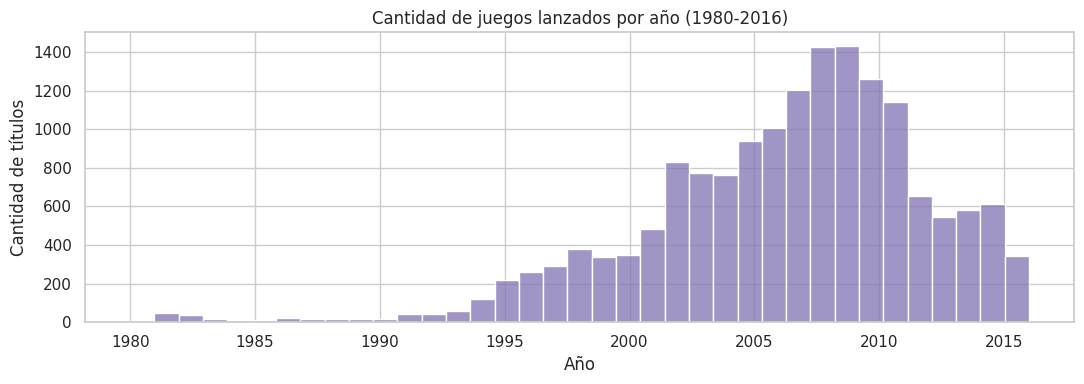

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(df['Year'], bins=37, ax=ax, color='#8172B2')
ax.set_title('Cantidad de juegos lanzados por año (1980-2016)')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de títulos')
plt.tight_layout()
plt.show()

**Interpretación:** los lanzamientos crecen sostenidamente desde los años 80, con un pico marcado alrededor de 2008-2009, y luego decrecen hacia el final del periodo cubierto por el dataset. Retomaremos este patrón, junto con una hipótesis sobre su causa, en el Análisis Temporal (Sección 7).

### Variables categóricas

**Pregunta:** ¿qué géneros concentran más títulos publicados?

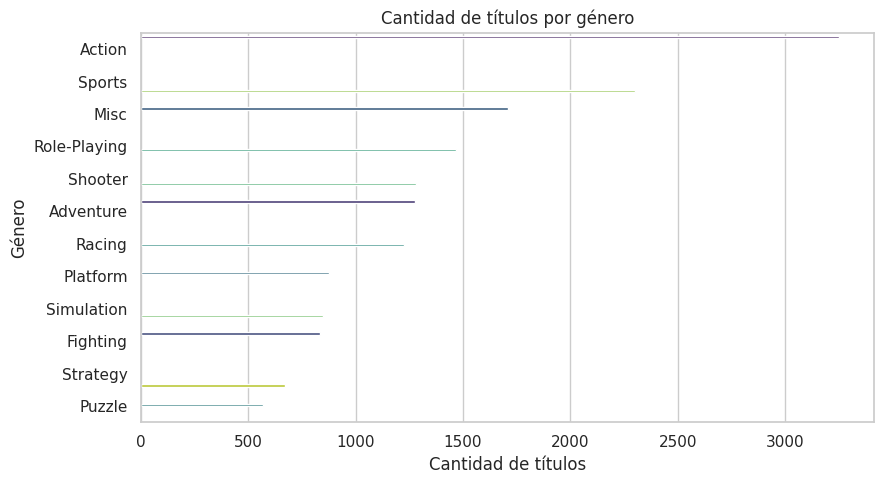

,Cantidad,% del total
Genre,,
Action,3252,19.9
Sports,2303,14.1
Misc,1710,10.5
Role-Playing,1469,9.0
Shooter,1282,7.9
Adventure,1276,7.8
Racing,1226,7.5
Platform,876,5.4
Simulation,850,5.2


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
orden_genero = df['Genre'].value_counts().index
sns.countplot(y='Genre', data=df, order=orden_genero, ax=ax, hue='Genre', palette='viridis', legend=False)
ax.set_title('Cantidad de títulos por género')
ax.set_xlabel('Cantidad de títulos')
ax.set_ylabel('Género')
plt.tight_layout()
plt.show()

freq_genero = df['Genre'].value_counts()
freq_genero_pct = (freq_genero / len(df) * 100).round(1)
pd.DataFrame({'Cantidad': freq_genero, '% del total': freq_genero_pct})

**Interpretación:** *Action* es, por amplio margen, el género con más títulos publicados , seguido de *Sports* y *Misc*. En el otro extremo, *Strategy* y *Puzzle* son los géneros con menos títulos. Más adelante (Sección 5) contrastaremos esta cantidad de títulos con las ventas que realmente generan, porque no son lo mismo.

**Pregunta:** ¿en qué plataformas se concentra la mayor cantidad de lanzamientos?

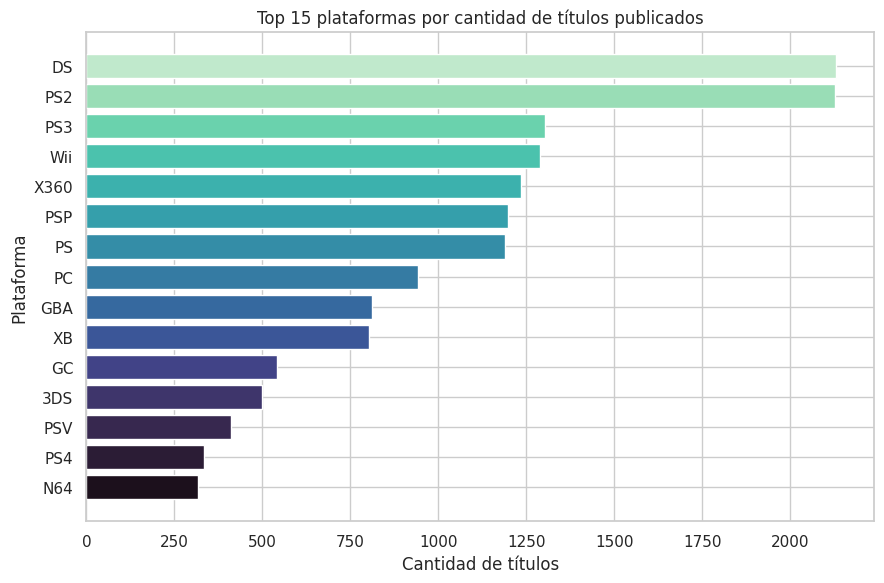

,Cantidad,% del total
Platform,,
DS,2132,13.1
PS2,2127,13.0
PS3,1303,8.0
Wii,1290,7.9
X360,1235,7.6
PSP,1197,7.3
PS,1189,7.3
PC,943,5.8
GBA,811,5.0


In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
freq_plat = df['Platform'].value_counts().head(15)

ax.barh(freq_plat.index[::-1], freq_plat.values[::-1], color=sns.color_palette('mako', n_colors=len(freq_plat)))
ax.set_title('Top 15 plataformas por cantidad de títulos publicados')
ax.set_xlabel('Cantidad de títulos')
ax.set_ylabel('Plataforma')
plt.tight_layout()
plt.show()

freq_plat_pct = (freq_plat / len(df) * 100).round(1)
pd.DataFrame({'Cantidad': freq_plat.head(10), '% del total': freq_plat_pct.head(10)})

**Interpretación:** *DS* y *PS2* concentran, por lejos, la mayor cantidad de títulos publicados, seguidas de *PS3*, *Wii* y *X360* , todas consolas de generaciones con catálogos muy extensos. Esto no implica necesariamente que sean las plataformas con más ventas acumuladas; lo verificamos en la siguiente sección.

---
## Sección 5 · Análisis bivariado

**Pregunta (categórica × numérica):** ¿qué géneros generan más ventas por título, más allá de cuántos títulos tengan publicados?

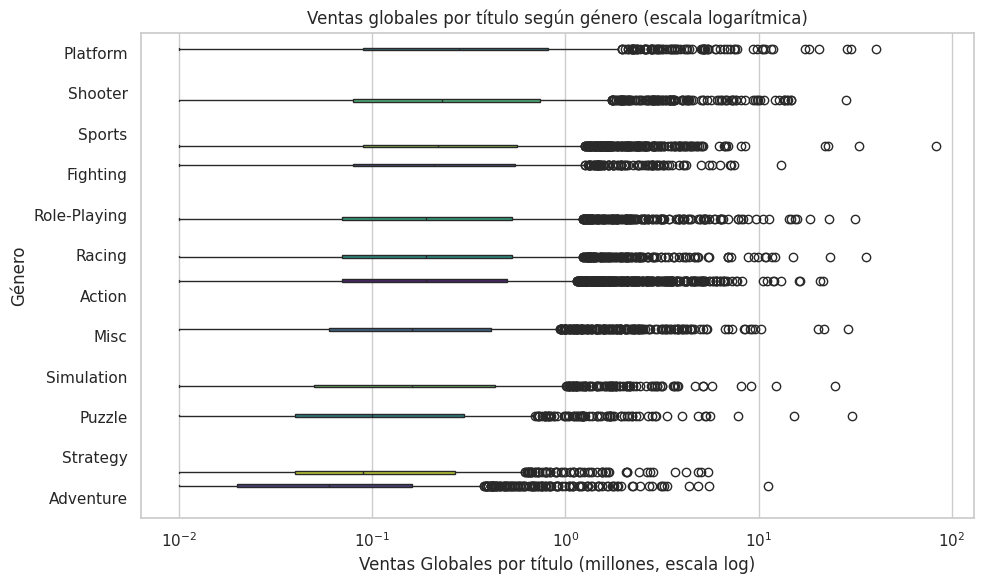

In [16]:
orden_genero_ventas = (df.groupby('Genre', observed=True)['Global_Sales']
                         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='Global_Sales', y='Genre', data=df, order=orden_genero_ventas,
            ax=ax, hue='Genre', palette='viridis', legend=False)
ax.set_xscale('log')
ax.set_title('Ventas globales por título según género (escala logarítmica)')
ax.set_xlabel('Ventas Globales por título (millones, escala log)')
ax.set_ylabel('Género')
plt.tight_layout()
plt.show()

**Interpretación:** aunque *Action* tiene más títulos publicados (Sección 4), géneros como *Platform*, *Shooter* y *Sports* muestran medianas de ventas por título más altas. Esto sugiere que no todos los géneros "rentan" igual por unidad publicada: algunos géneros con catálogos más pequeños (como *Platform*) logran ventas por título comparativamente altas, posiblemente por asociarse a franquicias consolidadas (Mario, Zelda, etc.).

**Pregunta (categórica × numérica):** ¿qué plataformas acumulan más ventas globales en total, y coincide con las que más títulos publicaron?

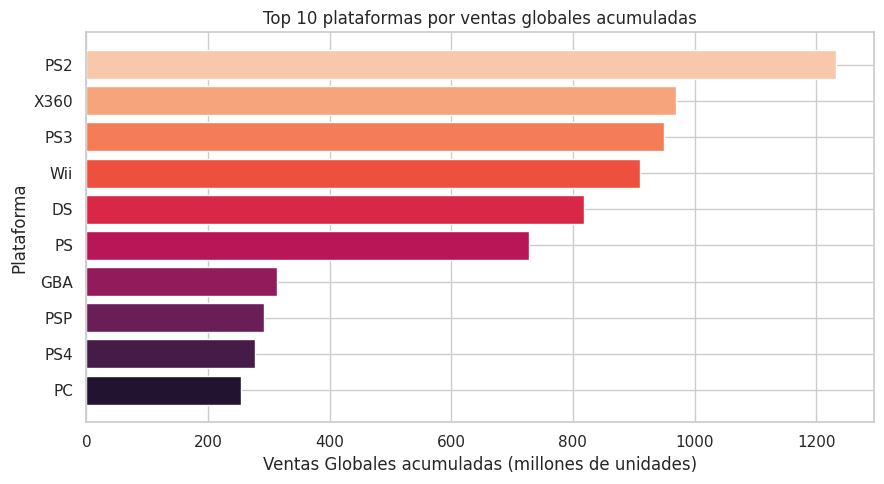

In [17]:
ventas_por_plataforma = (df.groupby('Platform', observed=True)['Global_Sales']
                         .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ventas_por_plataforma.index[::-1].astype(str),
        ventas_por_plataforma.values[::-1],
        color=sns.color_palette('rocket', n_colors=len(ventas_por_plataforma)))
ax.set_title('Top 10 plataformas por ventas globales acumuladas')
ax.set_xlabel('Ventas Globales acumuladas (millones de unidades)')
ax.set_ylabel('Plataforma')
plt.tight_layout()
plt.show()

**Interpretación:** *PS2* lidera en ventas totales acumuladas, superando a *X360*, *PS3* y *Wii*, a pesar de que *DS* tenía prácticamente el mismo número de títulos publicados que *PS2* (Sección 4). Esto indica que el catálogo de PS2 generó, en promedio, más ventas por título que el de DS ,coherente con PS2 siendo la consola más vendida de la historia en unidades de hardware, lo que amplifica las ventas de cada juego lanzado para ella.

**Pregunta (categórica × numérica):** ¿qué publishers dominan el mercado, y su liderazgo se explica por la cantidad de títulos que lanzan o por las ventas que logra cada título?

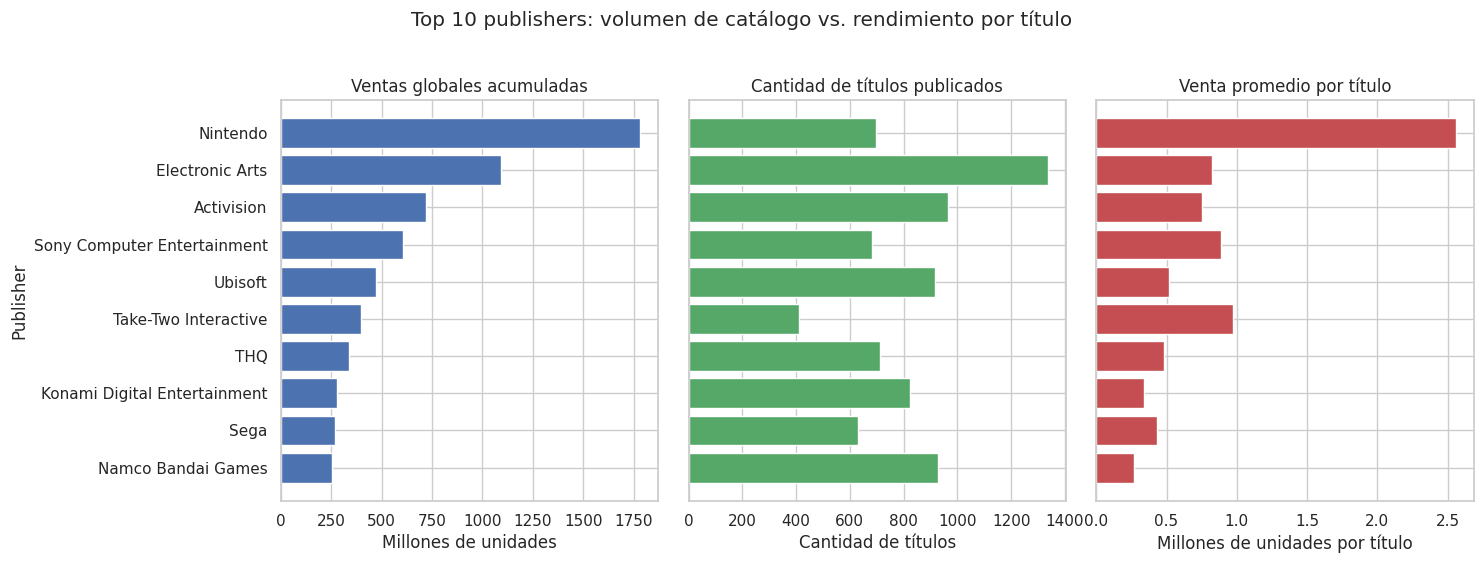

,Titulos,Ventas_totales,Venta_promedio
Publisher,,,
Nintendo,696,1784.43,2.56
Electronic Arts,1338,1093.38,0.82
Activision,966,721.41,0.75
Sony Computer Entertainment,682,607.28,0.89
Ubisoft,917,473.25,0.52
Take-Two Interactive,412,399.30,0.97
THQ,712,340.44,0.48
Konami Digital Entertainment,823,278.56,0.34
Sega,630,270.66,0.43


In [18]:
# Comparamos, para los 10 publishers con más ventas acumuladas, tres cosas distintas:
# cuántos títulos publicaron, cuánto vendieron en total y cuánto vende su título promedio.
resumen_pub = (df.groupby('Publisher', observed=True)
                 .agg(Titulos=('Name', 'size'),
                      Ventas_totales=('Global_Sales', 'sum'),
                      Venta_promedio=('Global_Sales', 'mean'))
                 .sort_values('Ventas_totales', ascending=False)
                 .head(10)
                 .round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
orden = resumen_pub.index[::-1].astype(str)

axes[0].barh(orden, resumen_pub['Ventas_totales'][::-1], color='#4C72B0')
axes[0].set_title('Ventas globales acumuladas')
axes[0].set_xlabel('Millones de unidades')
axes[0].set_ylabel('Publisher')

axes[1].barh(orden, resumen_pub['Titulos'][::-1], color='#55A868')
axes[1].set_title('Cantidad de títulos publicados')
axes[1].set_xlabel('Cantidad de títulos')

axes[2].barh(orden, resumen_pub['Venta_promedio'][::-1], color='#C44E52')
axes[2].set_title('Venta promedio por título')
axes[2].set_xlabel('Millones de unidades por título')

fig.suptitle('Top 10 publishers: volumen de catálogo vs. rendimiento por título', y=1.02)
plt.tight_layout()
plt.show()

resumen_pub

**Interpretación:** los dos primeros paneles cuentan historias distintas. Nintendo lidera claramente en ventas acumuladas (~1.784M de unidades) pese a publicar apenas 696 títulos, mientras Electronic Arts, con casi el doble de catálogo (1.338 títulos), queda muy por debajo en ventas totales. El tercer panel explica la diferencia: el título promedio de Nintendo vende **2.56M de unidades frente a 0.82M de EA**, más del triple. La conclusión es que el liderazgo de Nintendo no viene del volumen de lanzamientos sino del rendimiento por título, consistente con una estrategia de franquicias consolidadas (Mario, Pokémon, Zelda) asociadas además a sus propias consolas. Publishers como Ubisoft o Activision siguen el patrón opuesto: catálogos amplios con ventas promedio por título bastante más bajas.

**Pregunta (categórica × categórica):** ¿cómo ha cambiado la participación de cada género en las ventas totales, década a década?

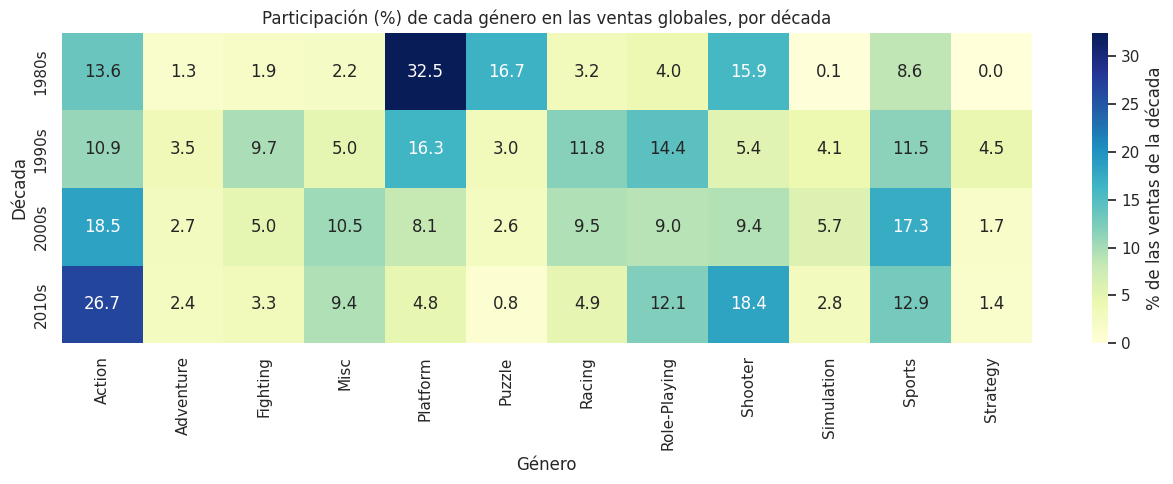

In [19]:
tabla_cruzada = (pd.crosstab(df['Decada'], df['Genre'], values=df['Global_Sales'],
                              aggfunc='sum', normalize='index') * 100)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(tabla_cruzada, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': '% de las ventas de la década'})
ax.set_title('Participación (%) de cada género en las ventas globales, por década')
ax.set_xlabel('Género')
ax.set_ylabel('Década')
plt.tight_layout()
plt.show()

**Interpretación:** el mapa de calor evidencia un cambio estructural en las preferencias de la industria. Los juegos de *Platform* pasaron de representar cerca de un tercio de las ventas en los años 80 a una fracción marginal en la década de 2010, mientras que *Action* y *Shooter* ganaron participación de forma sostenida hasta convertirse en los géneros dominantes de la década más reciente del dataset. *Sports* se mantiene relativamente estable en todas las décadas, lo que sugiere una demanda más constante (probablemente ligada a franquicias deportivas anuales).

**Pregunta (categórica × categórica):** ¿los géneros se reparten igual entre regiones, o hay géneros que dependen de un mercado en particular? Para responderlo usamos la variable derivada `Region_Dominante`, que indica en qué región concentra sus ventas cada título.

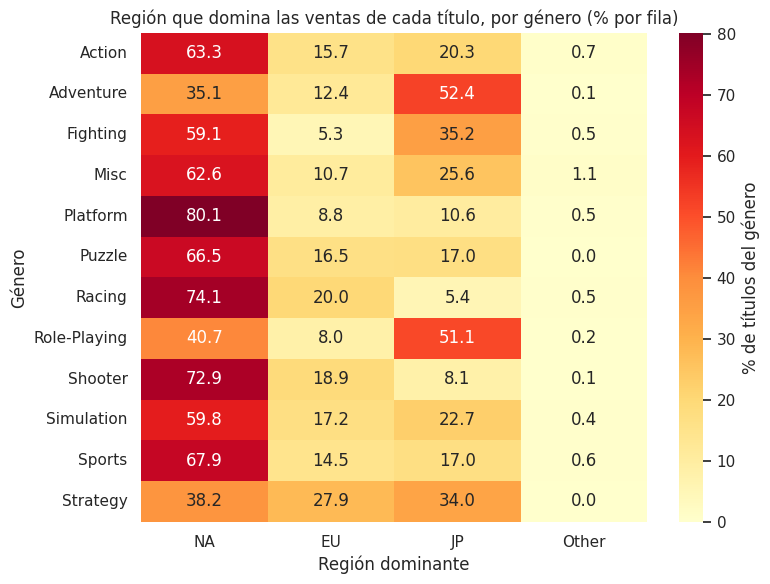

Region_Dominante,NA,EU,JP,Other
Genre,,,,
Action,63.3,15.7,20.3,0.7
Adventure,35.1,12.4,52.4,0.1
Fighting,59.1,5.3,35.2,0.5
Misc,62.6,10.7,25.6,1.1
Platform,80.1,8.8,10.6,0.5
Puzzle,66.5,16.5,17.0,0.0
Racing,74.1,20.0,5.4,0.5
Role-Playing,40.7,8.0,51.1,0.2
Shooter,72.9,18.9,8.1,0.1


In [20]:
# Crosstab de frecuencias puras: % de los títulos de cada género según la región que domina sus ventas
tabla_gen_region = pd.crosstab(df['Genre'], df['Region_Dominante'], normalize='index') * 100
tabla_gen_region = tabla_gen_region[['NA', 'EU', 'JP', 'Other']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(tabla_gen_region, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '% de títulos del género'})
ax.set_title('Región que domina las ventas de cada título, por género (% por fila)')
ax.set_xlabel('Región dominante')
ax.set_ylabel('Género')
plt.tight_layout()
plt.show()

tabla_gen_region.round(1)

**Interpretación:** la mayoría de los géneros tiene a Norteamérica como región dominante en más de la mitad de sus títulos, pero hay dos excepciones claras. en *Adventure* (52.4%) y *Role-Playing* (51.1%) es Japón quien domina en más de la mitad de los títulos, muy por encima del promedio del resto de géneros; en el otro extremo, *Shooter* y *Sports* son los géneros más volcados hacia NA y EU. Esto le pone un mecanismo concreto a la baja correlación de Japón que veremos en la Sección 6: no es que Japón compre "menos", es que compra **otros géneros**, y por eso el éxito de un título en NA no anticipa bien su desempeño allí.

---
## Sección 6 · Análisis multivariado y correlaciones

**Pregunta:** antes de mirar las correlaciones, ¿cuánto pesa realmente cada región dentro de las ventas globales?

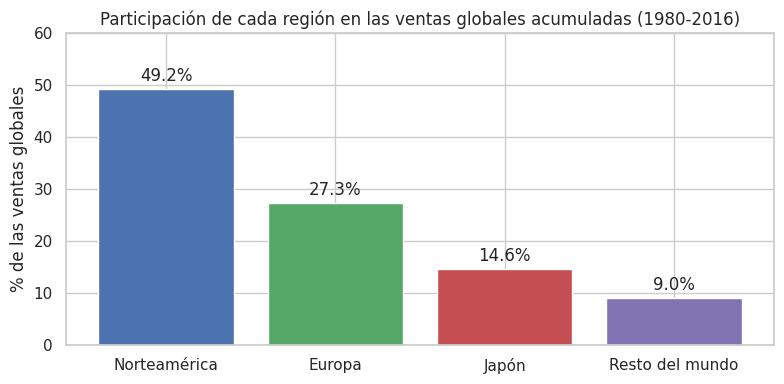

,Ventas (millones),% del total
NA_Sales,4333.2,49.2
EU_Sales,2409.1,27.3
JP_Sales,1284.2,14.6
Other_Sales,789.0,9.0


In [21]:
# Peso de cada región dentro del total de ventas registradas
ventas_region = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
participacion = (ventas_region / ventas_region.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
etiquetas = ['Norteamérica', 'Europa', 'Japón', 'Resto del mundo']
barras = ax.bar(etiquetas, participacion.values,
                color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.bar_label(barras, fmt='%.1f%%', padding=3)
ax.set_title('Participación de cada región en las ventas globales acumuladas (1980-2016)')
ax.set_ylabel('% de las ventas globales')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

pd.DataFrame({'Ventas (millones)': ventas_region.round(1), '% del total': participacion})

**Interpretación:** Norteamérica concentra el **49.2%** de todas las ventas registradas, seguida de Europa (27.3%), Japón (14.6%) y el resto del mundo (9.0%). Entre NA y EU explican más de tres cuartas partes del mercado, lo que da contexto a las correlaciones que analizamos a continuación: cualquier variable que se correlacione fuerte con `NA_Sales` lo hará también con `Global_Sales` casi por construcción, dado ese peso.

**Pregunta:** ¿qué tan relacionadas están las ventas entre las distintas regiones? ¿Alguna región se comporta de forma distinta al resto?

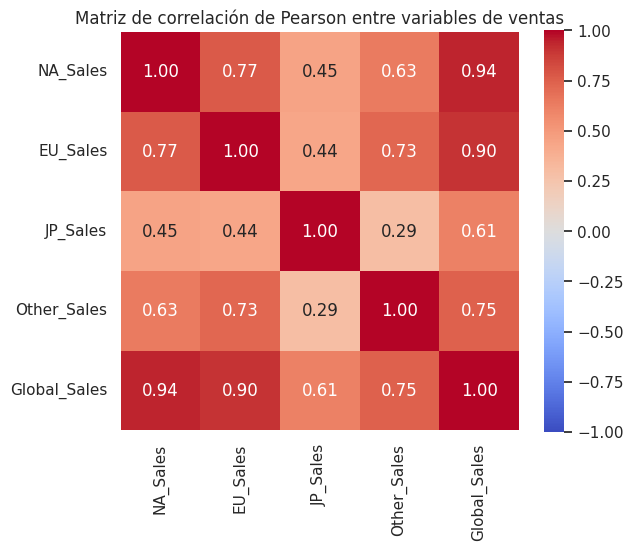

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.000,0.769,0.451,0.635,0.941
EU_Sales,0.769,1.000,0.436,0.726,0.903
JP_Sales,0.451,0.436,1.000,0.291,0.613
Other_Sales,0.635,0.726,0.291,1.000,0.748
Global_Sales,0.941,0.903,0.613,0.748,1.000


In [22]:
cols_num = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
matriz_corr = df[cols_num].corr(method='pearson')

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, square=True)
ax.set_title('Matriz de correlación de Pearson entre variables de ventas')
plt.tight_layout()
plt.show()

matriz_corr.round(3)

**Interpretación:** todas las correlaciones son positivas, como era de esperarse (un juego popular tiende a venderse bien en varias regiones a la vez). Sin embargo, hay diferencias importantes:

- `NA_Sales` es la región más correlacionada con `Global_Sales` (≈0.94), reflejando su gran peso relativo en el total.
- `NA_Sales` y `EU_Sales` están fuertemente correlacionadas entre sí (≈0.77): un juego que triunfa en Norteamérica casi siempre triunfa también en Europa.
- `JP_Sales` es, con diferencia, la región **menos correlacionada** con las demás (≈0.29–0.45): el mercado japonés se comporta de forma relativamente independiente del resto del mundo, probablemente por preferencias de género propias (mayor peso de *Role-Playing*, por ejemplo) y por la fuerza de publishers y plataformas locales. Esto responde directamente a la Pregunta de análisis 4 planteada en la Sección 1: sí existe una región (Japón) cuyo comportamiento se aleja claramente del patrón global.

> **Advertencia de lectura:** las correlaciones de cada región con `Global_Sales` (0.61 a 0.94) son en parte circulares, porque cada región es un componente del total: NA aparece en 0.94 principalmente porque representa el 49.2% de ese total. Las correlaciones informativas son las que se dan **entre regiones**, no las de cada región con el global.


**Pregunta:** la matriz anterior usa Pearson, que es sensible a valores extremos, y en la Sección 4 comprobamos que `Global_Sales` tiene una asimetría de ~17. ¿Se sostienen esas correlaciones si usamos Spearman, que trabaja con rangos y no con magnitudes?

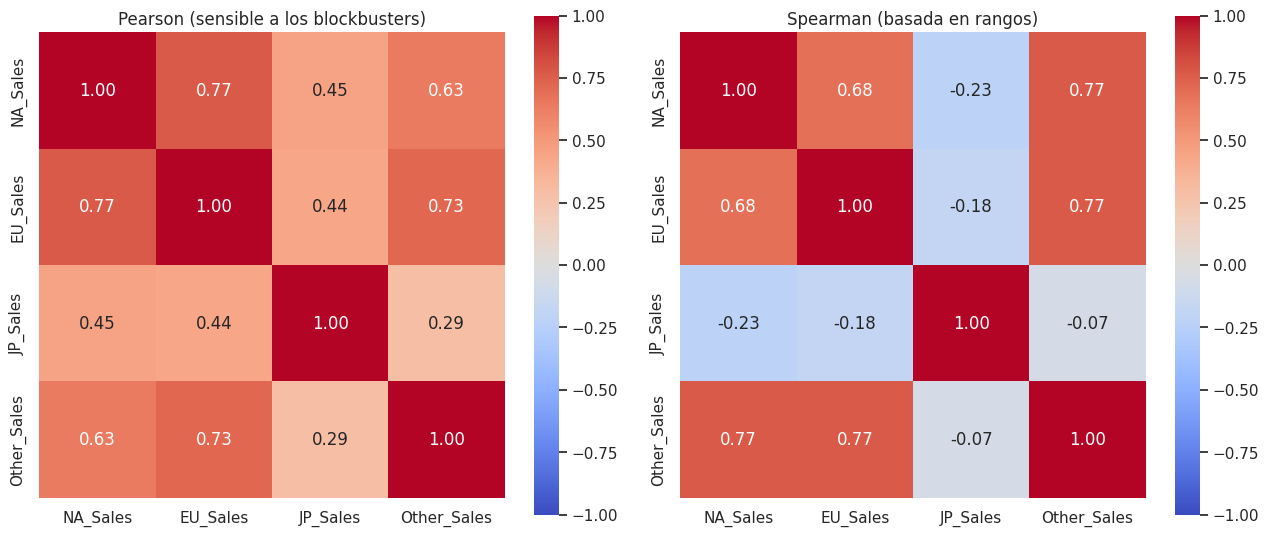

Porcentaje de títulos con ventas iguales a cero, por región:
NA_Sales       27.2
EU_Sales       34.5
JP_Sales       62.7
Other_Sales    39.0


In [23]:
cols_regiones = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
corr_pearson = df[cols_regiones].corr(method='pearson')
corr_spearman = df[cols_regiones].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, ax=axes[0])
axes[0].set_title('Pearson (sensible a los blockbusters)')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, ax=axes[1])
axes[1].set_title('Spearman (basada en rangos)')
plt.tight_layout()
plt.show()

# ¿Qué proporción de títulos simplemente no registra ventas en cada región?
ceros = (df[cols_regiones] == 0).mean().mul(100).round(1)
print("Porcentaje de títulos con ventas iguales a cero, por región:")
print(ceros.to_string())

**Interpretación (el hallazgo que más nos sorprendió):** la relación NA–EU se mantiene positiva y sólida con ambos métodos, así que ese resultado es robusto. Pero la relación **NA–JP cambia de signo**: pasa de +0.45 con Pearson a **−0.23 con Spearman**. La explicación es que la correlación positiva de Pearson la sostienen unos pocos megaéxitos que venden bien en todo el mundo a la vez; cuando se neutraliza el efecto de esas magnitudes extremas y se miran los rangos, el título *típico* que vende bien en Norteamérica tiende a vender **peor** en Japón. A esto se suma que el 62.7% de los títulos no registra ninguna venta en Japón. Es decir, Japón no está solo "menos correlacionado" con el resto del mundo: en el juego promedio la relación es directamente inversa, lo que refuerza aún más la necesidad de tratarlo como un mercado con lógica propia.

**Pregunta (trivariada):** ¿se mantiene la relación entre ventas de Norteamérica y Europa cuando se observa por género?

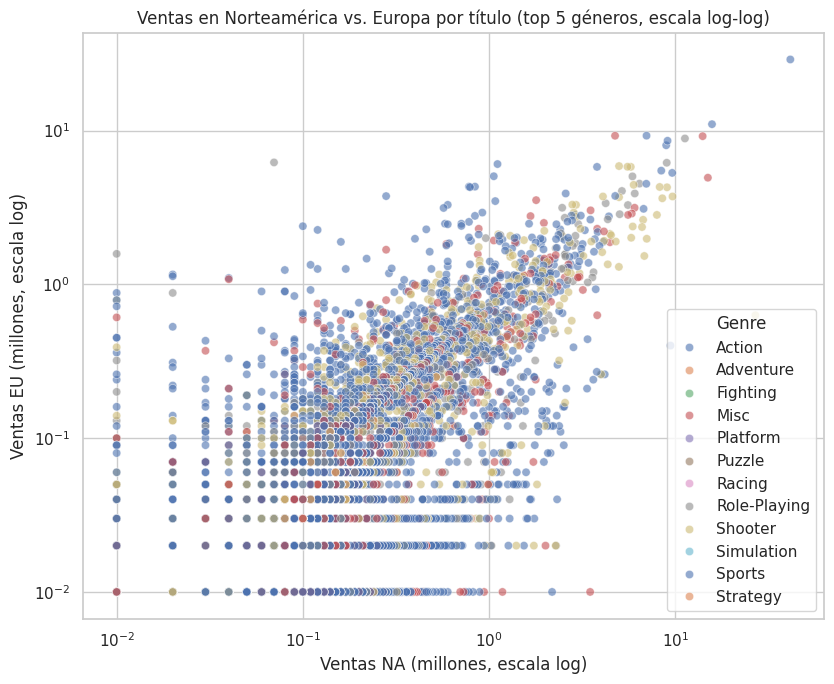

In [24]:
top_generos = df['Genre'].value_counts().head(5).index
df_top = df[df['Genre'].isin(top_generos)]

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.scatterplot(data=df_top, x='NA_Sales', y='EU_Sales', hue='Genre', alpha=0.6, ax=ax, palette='deep')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Ventas en Norteamérica vs. Europa por título (top 5 géneros, escala log-log)')
ax.set_xlabel('Ventas NA (millones, escala log)')
ax.set_ylabel('Ventas EU (millones, escala log)')
plt.tight_layout()
plt.show()

**Interpretación:** los puntos de los cinco géneros más frecuentes se distribuyen a lo largo de la misma diagonal ascendente, sin formar agrupaciones separadas por color, es decir, la relación positiva entre ventas de NA y EU observada en la matriz de correlación se sostiene de manera consistente dentro de cada género, no es un efecto agregado que oculte comportamientos distintos. Esto refuerza la idea de que NA y EU funcionan, en la práctica, como un mercado con dinámicas muy similares, independientemente del género del juego.

> **Nota metodológica:** al usar escala logarítmica en ambos ejes, los títulos con ventas iguales a cero en NA (27.2%) o en EU (34.5%) quedan fuera del gráfico. La lectura anterior aplica, entonces, a los títulos con presencia comercial en ambas regiones, no al catálogo completo.

---
## Sección 7 · Análisis temporal 

**Pregunta:** ¿cómo ha evolucionado el volumen de ventas por región a lo largo del tiempo?

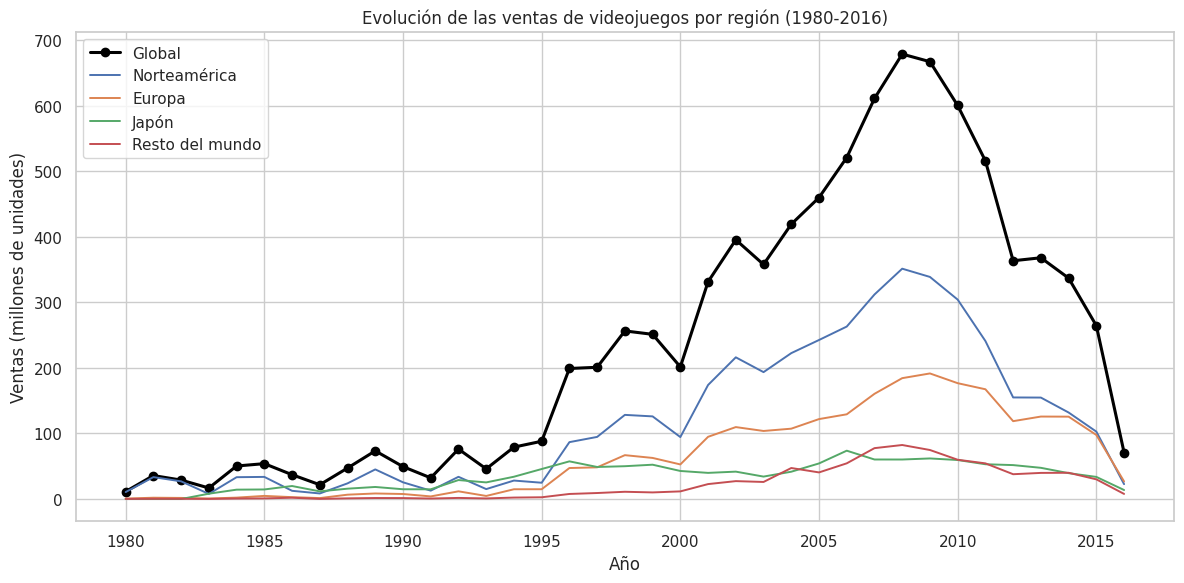

Year
2008    678.90
2009    667.30
2007    611.13
2010    600.45
2006    521.04
Name: Global_Sales, dtype: float64

In [25]:
ventas_año = df.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ventas_año.index, ventas_año['Global_Sales'], marker='o', linewidth=2.2, label='Global', color='black')
ax.plot(ventas_año.index, ventas_año['NA_Sales'], linewidth=1.4, label='Norteamérica')
ax.plot(ventas_año.index, ventas_año['EU_Sales'], linewidth=1.4, label='Europa')
ax.plot(ventas_año.index, ventas_año['JP_Sales'], linewidth=1.4, label='Japón')
ax.plot(ventas_año.index, ventas_año['Other_Sales'], linewidth=1.4, label='Resto del mundo')
ax.set_title('Evolución de las ventas de videojuegos por región (1980-2016)')
ax.set_xlabel('Año')
ax.set_ylabel('Ventas (millones de unidades)')
ax.legend()
plt.tight_layout()
plt.show()

ventas_año['Global_Sales'].sort_values(ascending=False).head(5)

**Interpretación:** las ventas globales crecen de forma sostenida desde 1980 hasta alcanzar su punto máximo en 2008 (~679M de unidades), año en que también se registró el mayor número de lanzamientos (Sección 4). A partir de 2011-2012 se observa una caída pronunciada en todas las regiones. Es importante interpretar esta caída con cautela: coincide con el auge de la distribución digital y de los juegos móviles, canales que este dataset no captura (solo registra ventas físicas/reportadas por VGChartz hasta aproximadamente 2016). Por lo tanto, la caída observada probablemente refleja, al menos en parte, una limitación de cobertura del dataset más que una contracción real del mercado de videojuegos.

**Pregunta:** ¿la cantidad de títulos lanzados por año sigue el mismo patrón que las ventas totales?

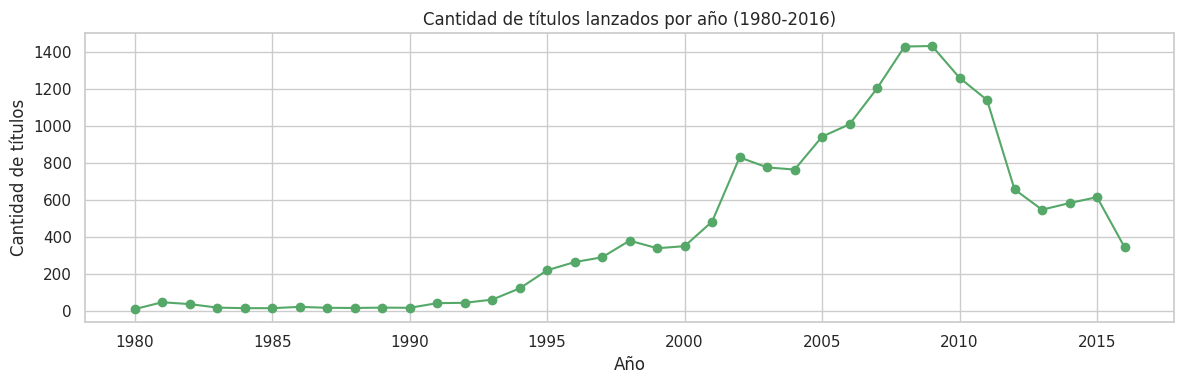

In [26]:
lanzamientos_año = df['Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lanzamientos_año.index, lanzamientos_año.values, marker='o', color='#55A868')
ax.set_title('Cantidad de títulos lanzados por año (1980-2016)')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de títulos')
plt.tight_layout()
plt.show()

**Interpretación:** el número de lanzamientos sigue un patrón casi idéntico al de las ventas totales, con su pico también entre 2008 y 2009. Esto refuerza la hipótesis de la limitación del dataset: la caída posterior a 2011 no es solo una caída en ventas por título, sino también una fuerte reducción en la cantidad de títulos físicos registrados, consistente con la migración de la industria hacia el modelo digital que este dataset no cubre.

---
## Sección 8 · Síntesis de hallazgos

### Insights de negocio

**1. Norteamérica es, por lejos, el mercado ancla de la industria.**
Norteamérica concentra el 49.2% de las ventas globales, seguida de Europa (27.3%), Japón (14.6%) y el resto del mundo (9.0%) (Sección 6). Las estrategias globales de marketing, fechas de lanzamiento y asignación de presupuesto deberían priorizar NA como mercado principal, tratando a EU como un mercado casi equivalente dada su altísima correlación con NA (0.77).

**2. El mercado es fuertemente "hit-driven".**
La mediana de ventas globales por título es de solo 0.17M de unidades, frente a un promedio de 0.54M, y el coeficiente de asimetría (~17) confirma que un número reducido de títulos "blockbuster" concentra la mayoría de los ingresos (Sección 4). Diversificar el portafolio de lanzamientos reduce el riesgo de depender de unos pocos éxitos, pero también implica que la identificación temprana de un potencial "hit" (vía franquicia, género o plataforma) es crítica para la rentabilidad.

**3. Japón se comporta como un mercado estructuralmente distinto.**
La correlación de `JP_Sales` con las demás regiones (0.29 a 0.45) es notablemente más baja que la correlación NA-EU (0.77), y al recalcularla con Spearman la relación NA-JP incluso se vuelve negativa: en el título promedio, vender bien en Norteamérica se asocia a vender peor en Japón (Sección 6). El mecanismo detrás está en la Sección 5: Japón concentra su demanda en géneros distintos, sobre todo *Adventure* y *Role-Playing*. Las decisiones de lanzamiento y localización para Japón deberían diseñarse de forma independiente, en lugar de replicar automáticamente la estrategia usada para NA/EU.

**4. El liderazgo de Nintendo se explica por calidad de franquicias, no por volumen.**
Nintendo lidera en ventas totales pese a publicar considerablemente menos títulos que Electronic Arts; su venta promedio por título más que triplica la de EA, lo que sugiere una estrategia centrada en franquicias fuertes y consistentes en lugar de un catálogo amplio (Sección 5). Para publishers medianos, apostar por pocas franquicias sólidas puede ser más rentable por título que maximizar el número de lanzamientos.

**5. Las preferencias de género cambiaron radicalmente entre décadas.**
Los juegos de plataformas (*Platform*) dominaban en los años 80 y perdieron casi toda su participación hacia la década de 2010, mientras *Action* y *Shooter* se consolidaron como los géneros con mayor participación reciente en ventas (Sección 5). Reevaluar la inversión en géneros "clásicos" en declive y priorizar *Action* y *Shooter* en nuevos desarrollos, sin descuidar *Sports*, que se mantiene estable en todas las décadas.

**6. La caída de ventas posterior a 2011 probablemente es un artefacto de cobertura del dataset, no una contracción real del mercado.**
Tanto las ventas totales como el número de lanzamientos caen de forma pronunciada después de 2011, coincidiendo con el auge de la distribución digital y móvil, canales que este dataset (basado en ventas físicas reportadas hasta 2016) no registra (Sección 7). Cualquier conclusión sobre el desempeño de la industria a partir de 2012 debe complementarse con fuentes de ventas digitales, y no debe interpretarse como evidencia de una industria en declive.

### Conclusiones y recomendación general

El análisis confirma que el mercado global de videojuegos, al menos en su componente físico hasta 2016, es un mercado concentrado geográficamente (dominado por NA y EU), concentrado en pocos títulos exitosos, y con una región (Japón) que exige un tratamiento diferenciado. Para un tomador de decisiones —sea un publisher, un fabricante de plataformas o un inversionista— la recomendación central es segmentar la estrategia por región y priorizar la inversión en los géneros de mayor tracción reciente (Action, Shooter, Sports), mientras se interpreta con cautela cualquier tendencia posterior a 2011 dada la limitación de cobertura del dataset identificada en la Sección 7.


---
## Declaración de uso de IA generativa

*(Política Nivel 3 del curso)*

- **Herramienta utilizada:** Claude y Copilot.
- **Tareas para las que se usó:** apoyo en la estructuración del flujo de trabajo de EDA , organización de las secciones exigidas por la guía del taller, generación de código base en Pandas/Matplotlib/Seaborn para las visualizaciones y tablas y en momentos de tener fallas con los codigos nos apoyabamos con copilot.
- **Cómo validamos los resultados de la IA:** todo el código sugerido se ejecutó y se contrastó contra el dataset antes de aceptarlo. Cuando una cifra aparecía en una interpretación, la verificamos recalculándola nosotros en el notebook (por ejemplo, los porcentajes de participación regional de la Sección 6 y las ventas promedio por publisher de la Sección 5, que originalmente citábamos sin mostrar la celda que los producía). También descartamos sugerencias que no nos convencieron: la IA propuso imputar `Year` con la mediana y decidimos descartar esas filas, porque el año de lanzamiento de un videojuego no se puede estimar a partir de las otras columnas.
- **Alcance de la IA en el análisis:** la IA no tomó decisiones finales de negocio ni de limpieza de datos; estas decisiones (por ejemplo, qué hacer con los valores faltantes de `Year` y con el registro duplicado de "Madden NFL 13") fueron evaluadas y validadas por el equipo con base en el diagnóstico presentado en la Sección 3.
